In [18]:
# Cell 1: Check GPU + Mount Drive
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

from google.colab import drive
drive.mount('/content/drive')

GPU available: False
GPU name: None
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# Cell 2: Install Dependencies
# This may take 2-3 minutes — run once per session

!pip install -q opencv-python-headless
!pip install -q dlib
!pip install -q numpy Pillow matplotlib
!pip install -q insightface onnxruntime
!pip install -q gradio

print("All packages installed!")

All packages installed!


In [20]:
from google.colab import files
import cv2

print("Upload SOURCE image:")
uploaded = files.upload()
source_filename = list(uploaded.keys())[0]

print("Upload TARGET image:")
uploaded2 = files.upload()
target_filename = list(uploaded2.keys())[0]

Upload SOURCE image:


Saving WhatsApp Image 2026-05-05 at 12.11.22 PM.jpeg to WhatsApp Image 2026-05-05 at 12.11.22 PM (2).jpeg
Upload TARGET image:


Saving WhatsApp Image 2026-05-05 at 12.47.01 PM.jpeg to WhatsApp Image 2026-05-05 at 12.47.01 PM (2).jpeg


In [21]:
import insightface
from insightface.app import FaceAnalysis

app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


In [22]:
import os, urllib.request

model_path = os.path.expanduser("~/.insightface/models/inswapper_128.onnx")
os.makedirs(os.path.dirname(model_path), exist_ok=True)

if not os.path.exists(model_path):
    print("Downloading model (~500MB)...")
    url = "https://github.com/deepinsight/insightface/releases/download/v0.7/inswapper_128.onnx"
    urllib.request.urlretrieve(url, model_path)
    print("Downloaded!")
else:
    print("Model already exists.")

Model already exists.


In [23]:
from insightface.model_zoo import get_model

swapper = get_model(model_path, download=False)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
inswapper-shape: [1, 3, 128, 128]


In [24]:
import cv2

def advanced_swap(source_path, target_path, output_path="result.jpg"):
    src = cv2.imread(source_path)
    dst = cv2.imread(target_path)

    src_faces = app.get(src)
    dst_faces = app.get(dst)

    if len(src_faces) == 0:
        print("No face in source!")
        return None
    if len(dst_faces) == 0:
        print("No face in target!")
        return None

    result = dst.copy()

    for face in dst_faces:
        result = swapper.get(result, face, src_faces[0], paste_back=True)

    cv2.imwrite(output_path, result)
    return result

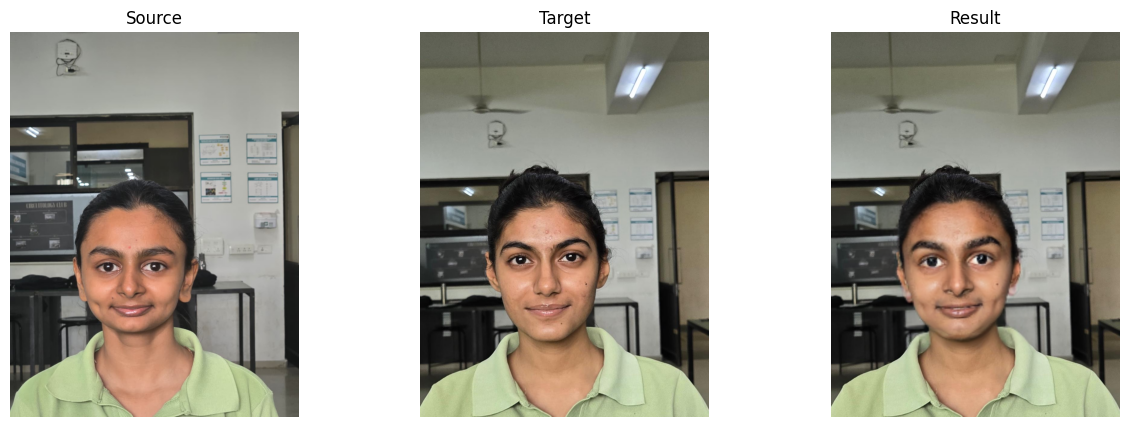

In [25]:

import matplotlib.pyplot as plt

result = advanced_swap(source_filename, target_filename)

if result is not None:
    src = cv2.cvtColor(cv2.imread(source_filename), cv2.COLOR_BGR2RGB)
    dst = cv2.cvtColor(cv2.imread(target_filename), cv2.COLOR_BGR2RGB)
    res = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 3, figsize=(15,5))
    ax[0].imshow(src); ax[0].set_title("Source"); ax[0].axis('off')
    ax[1].imshow(dst); ax[1].set_title("Target"); ax[1].axis('off')
    ax[2].imshow(res); ax[2].set_title("Result"); ax[2].axis('off')

    plt.show()

In [26]:
from google.colab import files
files.download("result.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>